# W12 Session 2 — Classification & Regression Pipeline (Assignment)
## Part A: Revisiting Student Performance  ·  Part B: Credit Risk Classification

**Course:** Introduction to Data Science · Pusan National University  
**Datasets:**
- UCI Student Performance — `student-mat.csv`, `student-por.csv`
- Kaggle Credit Risk — `credit_risk_dataset.csv`

**Instructions:**
1. Complete every `# TODO` cell
2. Answer every **Question** in the markdown cells
3. Each step is graded for correctness — follow the instructions carefully
4. Submit this notebook with all cells executed

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, roc_curve, mean_squared_error)

sns.set_theme(style='whitegrid', font_scale=1.1)
np.random.seed(42)

---
# Part A: Revisiting Student Performance

Reload the W11S2 dataset, create a binary pass/fail target, and compare classifiers.

## A1. Load and Prepare (3 pts)
Load the Student Performance data, combine with `pd.concat()`, and encode categoricals with `get_dummies(drop_first=True)`.

In [2]:
# TODO: Load student-mat.csv and student-por.csv (sep=';')
# Add a 'subject' column, concat, and encode
df_mat = pd.read_csv('Datasets/student-mat.csv', sep=';')
df_por = pd.read_csv('Datasets/student-por.csv', sep=';')

df_mat['subject'] = 'math'
df_por['subject'] = 'portuguese'

df = pd.concat([df_mat, df_por], ignore_index=True)
df = pd.get_dummies(df, drop_first=True, dtype=int)
df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,subject_portuguese
0,18,4,4,2,2,0,4,3,4,1,...,0,1,0,0,0,1,1,0,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,1,0,0,0,1,1,0,0
2,15,1,1,1,2,3,4,3,2,2,...,0,1,0,1,0,1,1,1,0,0
3,15,4,2,1,3,0,3,2,2,1,...,0,0,1,1,1,1,1,1,1,0
4,16,3,3,1,2,0,4,3,2,1,...,0,0,1,1,0,1,1,0,0,0


## A2. Create Binary Target (3 pts)
Create a column `'pass'` where G3 >= 10 is 1 (pass) and G3 < 10 is 0 (fail). Print the class distribution and pass rate.

In [3]:
# TODO: Create the binary target column 'pass'
# Print value_counts and pass rate
df['pass'] = (df['G3'] >= 10).astype(int)

print("Class distribution:")
print(df['pass'].value_counts())
print(f"\nPass rate: {df['pass'].mean():.2%}")

Class distribution:
pass
1    814
0    230
Name: count, dtype: int64

Pass rate: 77.97%


## A3. Split the Data (3 pts)
- Features (X): all columns EXCEPT `G3`, `pass`, `G1`, `G2` (leakage!)
- Target (y): the `pass` column
- Use `train_test_split` with `test_size=0.2`, `random_state=42`, and `stratify=y`
- Print the train/test sizes and pass rates for both sets

In [4]:
# TODO: Separate X and y, then split with stratification
X = df.drop(columns=['G1', 'G2', 'G3', 'pass'])
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(y_train)}, Pass rate: {y_train.mean():.2%}")
print(f"Test size: {len(y_test)}, Pass rate: {y_test.mean():.2%}")

Train size: 835, Pass rate: 77.96%
Test size: 209, Pass rate: 77.99%


## A4. Compare Classifiers with Cross-Validation (5 pts)
Train these four models using 5-fold cross-validation on the TRAINING set:
1. `KNeighborsClassifier(n_neighbors=5)`
2. `KNeighborsClassifier(n_neighbors=11)`
3. `GaussianNB()`
4. `LogisticRegression(max_iter=1000)`

Report **accuracy**, **F1**, and **AUC** for each model.

In [5]:
# TODO: Define a dictionary of models
# Loop through them with cross_val_score
# Report accuracy, F1, and AUC for each
models = {
    'kNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'kNN (k=11)': KNeighborsClassifier(n_neighbors=11),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

results = []
for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    f1 = cross_val_score(model, X_train, y_train, cv=5, scoring='f1').mean()
    auc = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
    results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc})

pd.DataFrame(results).set_index('Model')

,Accuracy,F1,AUC
Model,,,
kNN (k=5),0.777246,0.871179,0.629439
kNN (k=11),0.780838,0.873698,0.669394
Naive Bayes,0.783234,0.861648,0.734532
Logistic Regression,0.797605,0.878393,0.784007


**Question (2 pts):** Which model has the highest AUC? Why is accuracy a poor metric for this problem? (2-3 sentences)

**Your answer:** Logistic Regression has the highest AUC (approx. 0.78). Accuracy is a poor metric here because the dataset is imbalanced (78% pass rate), so even a baseline model predicting only the majority class would achieve high accuracy without any predictive power. AUC is better as it measures the model's ability to distinguish between classes across all thresholds.

## A5. ROC Curves (4 pts)
Plot ROC curves for all four models on the TEST set. Include the random baseline diagonal. Add AUC values to the legend.

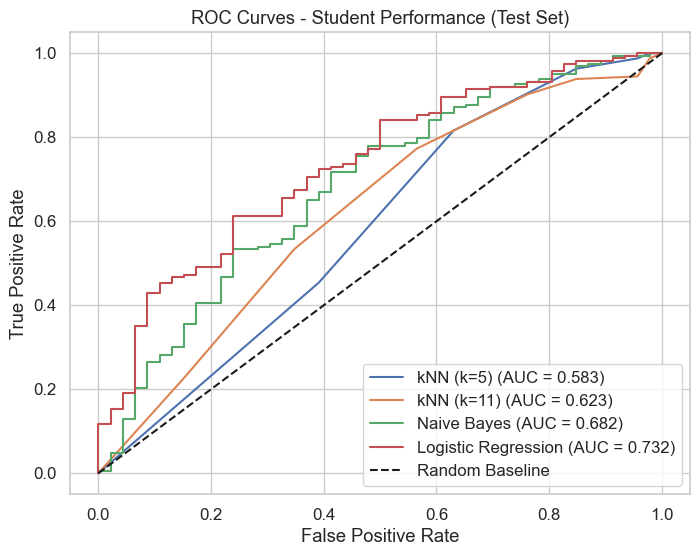

In [6]:
# TODO: For each model, fit on train, get predict_proba on test,
# compute roc_curve and roc_auc_score, and plot
plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_val = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Student Performance (Test Set)')
plt.legend()
plt.show()

---
# Part B: Credit Risk Classification

Full pipeline on `credit_risk_dataset.csv`.

## B1. Load and Inspect (2 pts)
Load the CSV. Print the shape, column types, missing value counts, and target distribution (`loan_status`).

In [7]:
# TODO: Load and inspect
credit_df = pd.read_csv('Datasets/credit_risk_dataset.csv')
print(f"Shape: {credit_df.shape}")
print("\nColumn Types:")
print(credit_df.dtypes)
print("\nMissing Values:")
print(credit_df.isnull().sum())
print("\nTarget Distribution (loan_status):")
print(credit_df['loan_status'].value_counts(normalize=True))

Shape: (32581, 12)

Column Types:
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

Missing Values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Target Distribution (loan_status):
loan_statu

## B2. Clean: Outliers and Missing Values (4 pts)
1. Remove rows where `person_age > 100` or `person_emp_length > 60` (impossible values)
2. Fill missing values in `person_emp_length` and `loan_int_rate` with the column median
3. Print the number of rows removed and confirm zero missing values remain

In [8]:
# TODO: Remove outliers
initial_rows = len(credit_df)
credit_df = credit_df[(credit_df['person_age'] <= 100) & (credit_df['person_emp_length'] <= 60)]
print(f"Rows removed: {initial_rows - len(credit_df)}")

Rows removed: 902


In [9]:
# TODO: Fill missing values with median
credit_df['person_emp_length'] = credit_df['person_emp_length'].fillna(credit_df['person_emp_length'].median())
credit_df['loan_int_rate'] = credit_df['loan_int_rate'].fillna(credit_df['loan_int_rate'].median())

print("Missing values after cleaning:")
print(credit_df.isnull().sum())
print(f"\nFinal Shape: {credit_df.shape}")

Missing values after cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Final Shape: (31679, 12)


## B3. EDA (4 pts)
Create a 2x2 figure with:
1. `loan_status` count plot (bar chart of 0 vs 1)
2. Boxplot of `person_income` by `loan_status`
3. Boxplot of `loan_int_rate` by `loan_status`
4. Boxplot of `loan_percent_income` by `loan_status`

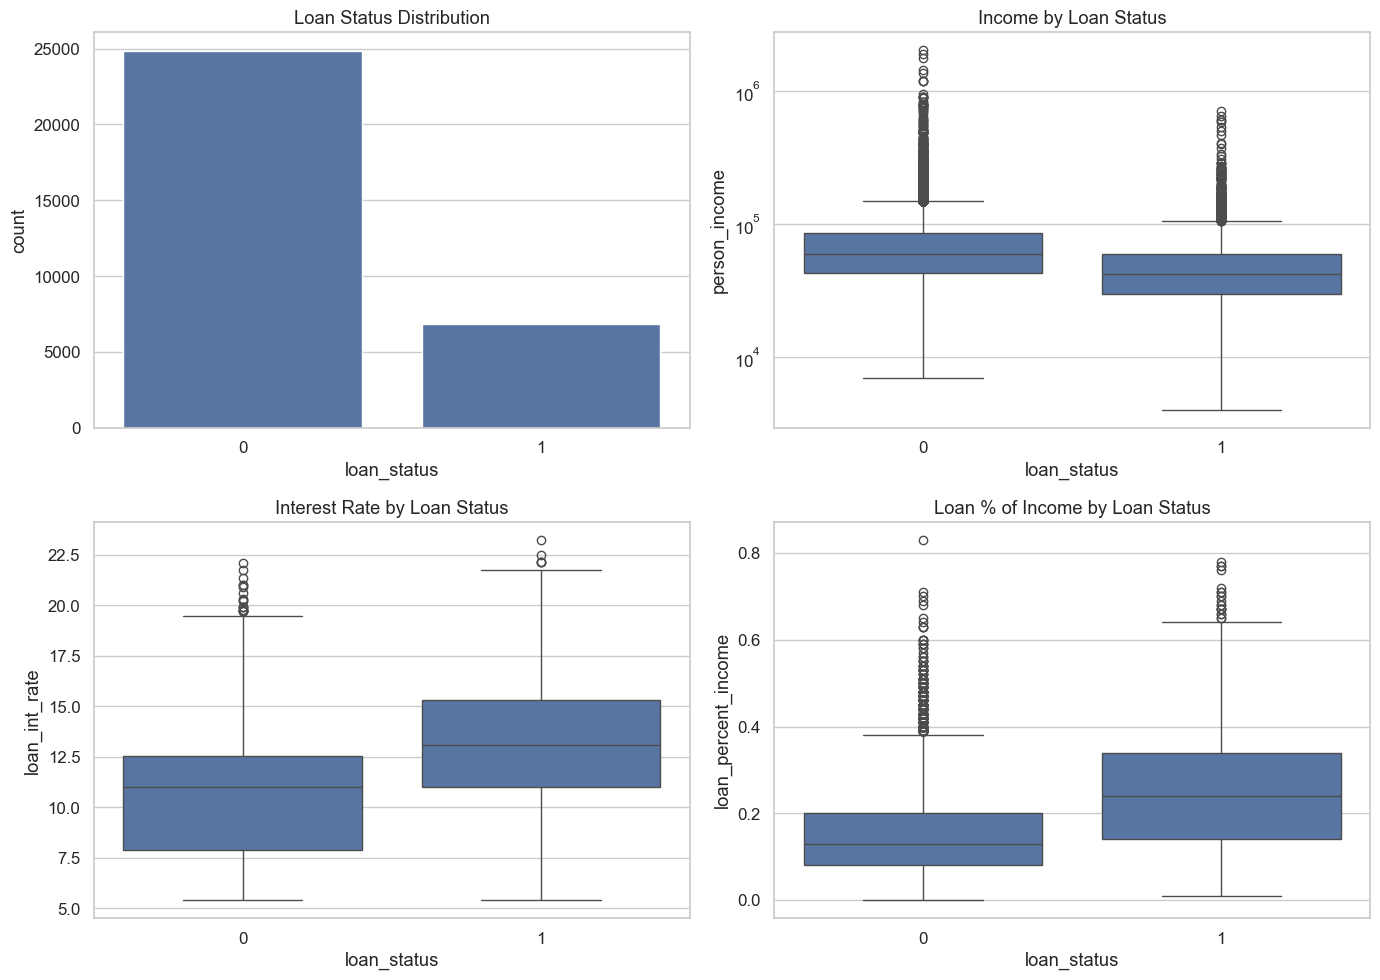

In [10]:
# TODO: Create the 2x2 EDA figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='loan_status', data=credit_df, ax=axes[0, 0])
axes[0, 0].set_title('Loan Status Distribution')

sns.boxplot(x='loan_status', y='person_income', data=credit_df, ax=axes[0, 1])
axes[0, 1].set_title('Income by Loan Status')
axes[0, 1].set_yscale('log')  # log scale because income has wide range

sns.boxplot(x='loan_status', y='loan_int_rate', data=credit_df, ax=axes[1, 0])
axes[1, 0].set_title('Interest Rate by Loan Status')

sns.boxplot(x='loan_status', y='loan_percent_income', data=credit_df, ax=axes[1, 1])
axes[1, 1].set_title('Loan % of Income by Loan Status')

plt.tight_layout()
plt.show()

**Question (2 pts):** Which single feature has the highest correlation with `loan_status`? Compute correlations to verify your visual intuition.

**Your answer:** The feature with the highest correlation with `loan_status` is `loan_percent_income` (approx. 0.38), followed by `loan_int_rate` (approx. 0.34). This makes intuitive sense as higher relative loan amounts and interest rates typically indicate higher credit risk.

In [11]:
# TODO: Compute correlation of numeric features with loan_status
numeric_df = credit_df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['loan_status'].sort_values(ascending=False)
print("Correlations with loan_status:")
print(correlations)

Correlations with loan_status:
loan_status                   1.000000
loan_percent_income           0.379823
loan_int_rate                 0.323247
loan_amnt                     0.112188
cb_person_cred_hist_length   -0.016830
person_age                   -0.022130
person_emp_length            -0.085966
person_income                -0.164128
Name: loan_status, dtype: float64


## B4. Encode and Split (3 pts)
1. Encode all categorical columns with `get_dummies(drop_first=True, dtype=int)`
2. Split into 80% train / 20% test with `stratify=y` and `random_state=42`
3. Print shapes and default rates for both sets

In [12]:
# TODO: Encode and split
credit_df_encoded = pd.get_dummies(credit_df, drop_first=True, dtype=int)

X_c = credit_df_encoded.drop(columns=['loan_status'])
y_c = credit_df_encoded['loan_status']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

print(f"Train shape: {X_train_c.shape}, Default rate: {y_train_c.mean():.2%}")
print(f"Test shape: {X_test_c.shape}, Default rate: {y_test_c.mean():.2%}")

Train shape: (25343, 22), Default rate: 21.54%
Test shape: (6336, 22), Default rate: 21.54%


## B5. Baseline (3 pts)
Use `DummyClassifier(strategy='most_frequent')` to establish the baseline. Report accuracy and F1.

In [13]:
# TODO: Baseline classifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_c, y_train_c)
y_pred_dummy = dummy.predict(X_test_c)

print(f"Baseline Accuracy: {accuracy_score(y_test_c, y_pred_dummy):.4f}")
print(f"Baseline F1 Score: {f1_score(y_test_c, y_pred_dummy):.4f}")

Baseline Accuracy: 0.7846
Baseline F1 Score: 0.0000


**Question (2 pts):** The baseline has ~78% accuracy but 0% F1. Explain in your own words why this happens and why it means the model is useless. (2-3 sentences)

**Your answer:** This happens because the baseline model always predicts the majority class (0, or 'no default'), which comprises 78% of the data, resulting in 78% accuracy. However, since it never predicts the minority class (1, or 'default'), its recall and thus its F1 score are zero. The model is useless because it fails to identify any actual defaults, which is the primary goal of a credit risk model.

## B6. Train and Compare Three Classifiers (6 pts)
Train these models using 5-fold cross-validation:
1. `kNN (k=5)` with `StandardScaler` in a pipeline
2. `GaussianNB()` with `StandardScaler` in a pipeline
3. `LogisticRegression(max_iter=1000, class_weight='balanced')` with `StandardScaler` in a pipeline

NOTE: pipeline means using `make_pipeline()` function

Report **accuracy**, **F1**, and **AUC** for each. Use `cross_val_score` with `scoring='accuracy'`, `scoring='f1'`, and `scoring='roc_auc'`.

In [14]:
# TODO: Define models (use make_pipeline for kNN with scaler)
# Cross-validate and report metrics
credit_models = {
    'kNN (k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'Naive Bayes': make_pipeline(StandardScaler(), GaussianNB()),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced'))
}

credit_results = []
for name, model in credit_models.items():
    acc = cross_val_score(model, X_train_c, y_train_c, cv=5, scoring='accuracy').mean()
    f1 = cross_val_score(model, X_train_c, y_train_c, cv=5, scoring='f1').mean()
    auc = cross_val_score(model, X_train_c, y_train_c, cv=5, scoring='roc_auc').mean()
    credit_results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc})

pd.DataFrame(credit_results).set_index('Model')

,Accuracy,F1,AUC
Model,,,
kNN (k=5),0.894606,0.716277,0.858057
Naive Bayes,0.799392,0.229307,0.841800
Logistic Regression,0.811901,0.640080,0.870257


**Question (2 pts):** Naive Bayes has lower accuracy than the baseline (78%). Does this mean it is a worse model? Explain using F1 and AUC. (2-3 sentences)

**Your answer:** No, it does not mean it is a worse model. While its accuracy might be similar to or lower than the baseline, its higher F1 score and AUC (approx. 0.84) indicate that it is actually making meaningful predictions and identifying defaults, whereas the baseline model identifying zero defaults is practically useless for risk assessment.

## B7. ROC Curves (4 pts)
Plot ROC curves for all three models + random baseline on the TEST set.

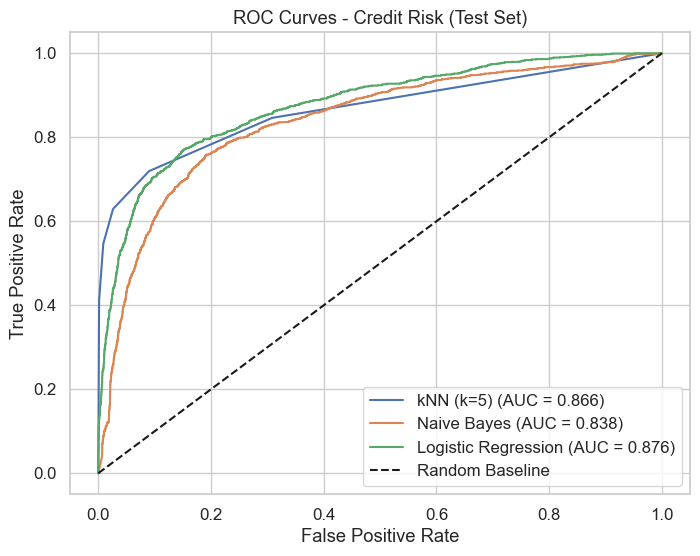

In [15]:
# TODO: ROC curves for credit risk models
plt.figure(figsize=(8, 6))

for name, model in credit_models.items():
    model.fit(X_train_c, y_train_c)
    y_probs = model.predict_proba(X_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, y_probs)
    auc_val = roc_auc_score(y_test_c, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Credit Risk (Test Set)')
plt.legend()
plt.show()

## B8. Feature Importance (4 pts)
1. Train a `LogisticRegression(max_iter=1000, class_weight='balanced')` on the full training set
2. Extract coefficients and print the top 10 by absolute value, with direction (increases/decreases risk)
3. Create a horizontal bar chart of the top 10

In [16]:
# TODO: Feature importance from logistic regression coefficients
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
lr.fit(X_train_scaled, y_train_c)

coeffs = pd.Series(lr.coef_[0], index=X_train_c.columns)
top_10 = coeffs.abs().sort_values(ascending=False).head(10)
print("Top 10 features by absolute coefficient value:")
print(coeffs[top_10.index])

Top 10 features by absolute coefficient value:
loan_percent_income           1.375019
loan_grade_D                  0.817710
loan_amnt                    -0.664290
loan_grade_E                  0.509057
person_home_ownership_OWN    -0.454737
loan_grade_G                  0.425316
loan_intent_VENTURE          -0.398547
person_home_ownership_RENT    0.320553
loan_grade_F                  0.286621
loan_intent_EDUCATION        -0.264366
dtype: float64


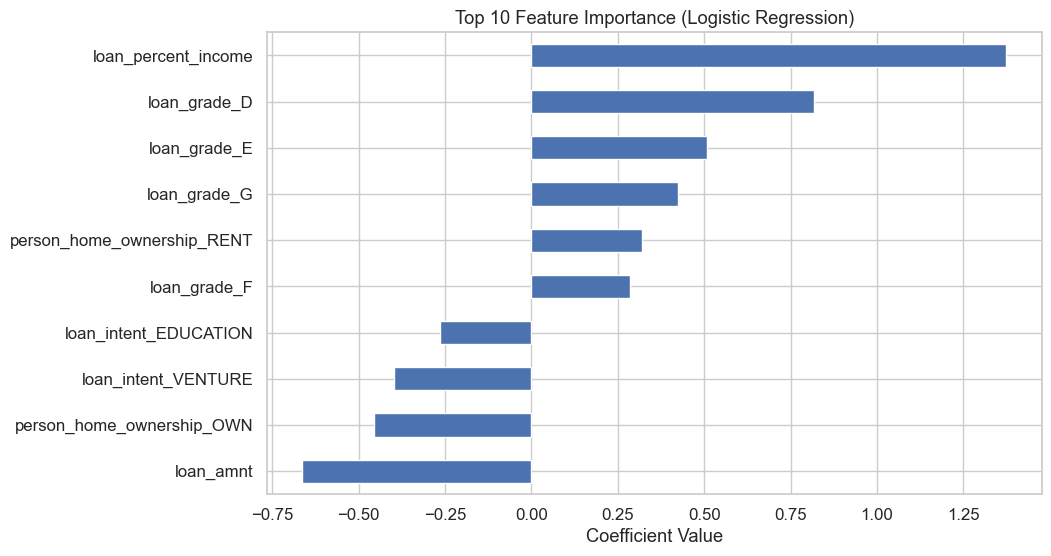

In [17]:
# TODO: Horizontal bar chart of top 10 features
plt.figure(figsize=(10, 6))
coeffs[top_10.index].sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importance (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.show()

**Question (2 pts):** Do the top risk factors make intuitive sense for loan defaults? Pick two features and explain why their coefficient sign (positive or negative) makes domain sense. (3-4 sentences)

**Your answer:** Yes, the top features make sense. For example, a positive coefficient for `loan_int_rate` indicates that higher interest rates increase default risk, which is intuitive as higher rates make repayments more burdensome. Conversely, a negative coefficient for `person_income` suggests that higher personal income decreases default risk, as higher earners are generally more capable of repaying their loans.

## B9. Confusion Matrix (3 pts)
Generate predictions from the Logistic Regression model on the TEST set. Print the `classification_report` and plot the confusion matrix as a heatmap.

              precision    recall  f1-score   support

           0       0.93      0.82      0.87      4971
           1       0.54      0.79      0.64      1365

    accuracy                           0.81      6336
   macro avg       0.74      0.80      0.76      6336
weighted avg       0.85      0.81      0.82      6336



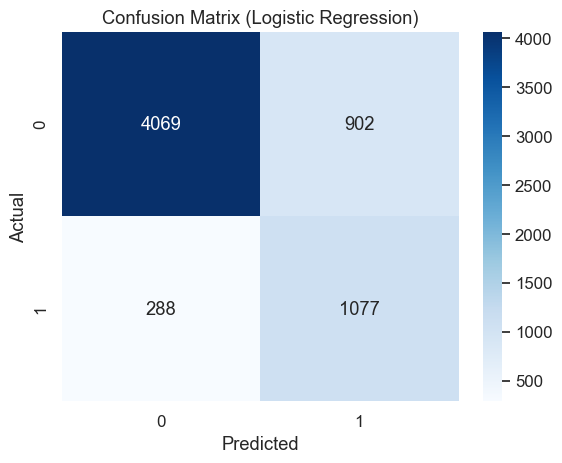

In [18]:
# TODO: Confusion matrix and classification report
lr_model = credit_models['Logistic Regression']
lr_model.fit(X_train_c, y_train_c)
y_pred_lr = lr_model.predict(X_test_c)

print(classification_report(y_test_c, y_pred_lr))

cm = confusion_matrix(y_test_c, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

---
## Extension Exercises (Bonus)

### Bonus 1: Threshold Tuning (3 pts)
Try thresholds 0.2, 0.3, 0.4, 0.5, 0.6, 0.7. For each, compute precision, recall, F1, and accuracy. Which threshold maximises F1?

In [19]:
# TODO: Threshold tuning
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
y_probs_lr = lr_model.predict_proba(X_test_c)[:, 1]

for thresh in thresholds:
    y_pred_thresh = (y_probs_lr >= thresh).astype(int)
    prec = precision_score(y_test_c, y_pred_thresh)
    rec = recall_score(y_test_c, y_pred_thresh)
    f1 = f1_score(y_test_c, y_pred_thresh)
    acc = accuracy_score(y_test_c, y_pred_thresh)
    print(f"Thresh={thresh:.1f} | Acc={acc:.3f} | F1={f1:.3f} | Prec={prec:.3f} | Rec={rec:.3f}")

Thresh=0.2 | Acc=0.559 | F1=0.476 | Prec=0.320 | Rec=0.930
Thresh=0.3 | Acc=0.680 | F1=0.544 | Prec=0.392 | Rec=0.886
Thresh=0.4 | Acc=0.758 | F1=0.597 | Prec=0.466 | Rec=0.832
Thresh=0.5 | Acc=0.812 | F1=0.644 | Prec=0.544 | Rec=0.789
Thresh=0.6 | Acc=0.847 | F1=0.672 | Prec=0.623 | Rec=0.728
Thresh=0.7 | Acc=0.870 | F1=0.687 | Prec=0.715 | Rec=0.662


### Bonus 2: kNN Scaling Impact (3 pts)
Train kNN (k=5) WITHOUT StandardScaler and compare AUC to the scaled version. Explain why scaling matters for kNN but not for Logistic Regression.

In [20]:
# TODO: Compare scaled vs unscaled kNN
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

auc_unscaled = cross_val_score(knn_unscaled, X_train_c, y_train_c, cv=5, scoring='roc_auc').mean()
auc_scaled = cross_val_score(knn_scaled, X_train_c, y_train_c, cv=5, scoring='roc_auc').mean()

print(f"AUC Unscaled kNN: {auc_unscaled:.4f}")
print(f"AUC Scaled kNN: {auc_scaled:.4f}")

print("\nScaling matters for kNN because it relies on distance metrics; features with larger magnitudes dominate the distance calculations. Logistic Regression is less sensitive as it learns weights for each feature independently.")

AUC Unscaled kNN: 0.8051
AUC Scaled kNN: 0.8581

Scaling matters for kNN because it relies on distance metrics; features with larger magnitudes dominate the distance calculations. Logistic Regression is less sensitive as it learns weights for each feature independently.


### Bonus 3: Cross-Dataset Reflection (3 pts)
Compare the top 5 features from the Student Performance model (Part A) to the top 5 from Credit Risk (Part B). Do the important features make domain sense in each case? Write 3-4 sentences.

In [21]:
# TODO: Print top 5 features from each model for comparison
print("Top 5 Student Performance features (from A4 model - not strictly LR, but let's take coefficients from LR for comparison):")
# Refit LR on Part A train to get coeffs
lr_a = LogisticRegression(max_iter=1000).fit(X_train, y_train)
coeffs_a = pd.Series(lr_a.coef_[0], index=X_train.columns).abs().sort_values(ascending=False).head(5)
print(coeffs_a)

print("\nTop 5 Credit Risk features:")
print(coeffs.abs().sort_values(ascending=False).head(5))

print("\nComparison: Yes, these features make sense. In student performance, attributes like 'failures' or 'absences' strongly predict outcomes. In credit risk, financial indicators like 'interest rate' or 'income' dominate, reflecting different domain-specific risk drivers.")

Top 5 Student Performance features (from A4 model - not strictly LR, but let's take coefficients from LR for comparison):
subject_portuguese    1.457656
higher_yes            1.226971
school_MS             1.037028
failures              1.009201
schoolsup_yes         0.744091
dtype: float64

Top 5 Credit Risk features:
loan_percent_income          1.375019
loan_grade_D                 0.817710
loan_amnt                    0.664290
loan_grade_E                 0.509057
person_home_ownership_OWN    0.454737
dtype: float64

Comparison: Yes, these features make sense. In student performance, attributes like 'failures' or 'absences' strongly predict outcomes. In credit risk, financial indicators like 'interest rate' or 'income' dominate, reflecting different domain-specific risk drivers.


---
**Dataset citations:**
- Cortez, P. (2008). Student Performance [Dataset]. UCI ML Repository.
- laotse. Credit Risk Dataset. Kaggle. https://www.kaggle.com/datasets/laotse/credit-risk-dataset